In [5]:
!pip install networkx rouge-score

In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import networkx as nx
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/danielwillgeorge/glove6b100dtxt'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [16]:
import os
os.listdir("/kaggle/input/datasets/sunnysai12345/news-summary")

['news_summary_more.csv', 'news_summary.csv']

In [17]:
df = pd.read_csv("/kaggle/input/datasets/sunnysai12345/news-summary/news_summary.csv", encoding="latin-1")

In [18]:
df = df.dropna(subset=["text"])
df["text"] = df["text"].astype(str)
df = df.reset_index(drop=True)
print("Total rows:", len(df))
df.head()

Total rows: 4514


,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",Daman & Diu revokes mandatory Rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,The Administration of Union Territory Daman an...,The Daman and Diu administration on Wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",Malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,Malaika Arora slammed an Instagram user who tr...,"From her special numbers to TV?appearances, Bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'Virgin' now corrected to 'Unmarried' in IGIMS...,http://www.hindustantimes.com/patna/bihar-igim...,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",Hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,Hotels in Maharashtra will train their staff t...,Hotels in Mumbai and other Indian cities are t...


In [19]:
df = df[["ctext", "headlines"]]
df = df.rename(columns={
    "ctext": "input_text",
    "headlines": "reference_summary"
})
df = df.reset_index(drop=True)

In [20]:
df.head()

,input_text,reference_summary
0,The Daman and Diu administration on Wednesday ...,Daman & Diu revokes mandatory Rakshabandhan in...
1,"From her special numbers to TV?appearances, Bo...",Malaika slams user who trolled her for 'divorc...
2,The Indira Gandhi Institute of Medical Science...,'Virgin' now corrected to 'Unmarried' in IGIMS...
3,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Aaj aapne pakad liya: LeT man Dujana before be...
4,Hotels in Mumbai and other Indian cities are t...,Hotel staff to get training to spot signs of s...


In [227]:
stop_words = stopwords.words("english")
print(stop_words[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [228]:
def get_sentence_vector(sentence):
    words = word_tokenize(sentence.lower())
    vectors = []
    for word in words:
        if word in word_embeddings:
            vectors.append(word_embeddings[word])
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

In [229]:
import networkx as nx
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
def glove_textrank_summary(text, top_n=1):
    sentences = sent_tokenize(str(text))
    if len(sentences) <= top_n:
        return text
    sentence_vectors = []
    
    for s in sentences:
        vec = get_sentence_vector(s)
        
        if np.linalg.norm(vec) == 0:
            vec = np.random.normal(0, 1e-6, size=len(vec))
        
        norm = np.linalg.norm(vec)
        if norm != 0:
            vec = vec / norm
            
        sentence_vectors.append(vec)
    
    sentence_vectors = np.array(sentence_vectors)
    
    sim_mat = cosine_similarity(sentence_vectors)
    
    sim_mat = np.nan_to_num(sim_mat)
    sim_mat[sim_mat < 0] = 0
    np.fill_diagonal(sim_mat, 0)
    
    nx_graph = nx.from_numpy_array(sim_mat)
    
    try:
        scores = nx.pagerank(
            nx_graph,
            alpha=0.85,
            max_iter=1000,
            tol=1e-4
        )
    except nx.PowerIterationFailedConvergence:
        scores = {i: 1/len(sentences) for i in range(len(sentences))}
    
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    top_sentences = sorted([ranked[i][0] for i in range(top_n)])
    
    summary = " ".join([sentences[i] for i in top_sentences])
    
    return summary


In [230]:
text_sample = str(df["text"][0])

print("ORIGINAL:\n", text_sample)
print("\nSUMMARY:\n", glove_textrank_summary(text_sample, top_n=1))


ORIGINAL:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.

SUMMARY:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7.


In [ ]:
df_small = df.iloc[:50].copy()

df_small["glove_summary"] = df_small["text"].apply(
    lambda x: glove_textrank_summary(x, top_n=1)
)

df_small[["text", "glove_summary"]].head()

,text,glove_summary
0,The Administration of Union Territory Daman an...,The Administration of Union Territory Daman an...
1,Malaika Arora slammed an Instagram user who tr...,"""Her life now is all about wearing short cloth..."
2,The Indira Gandhi Institute of Medical Science...,"The institute, however, faced strong backlash ..."
3,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,"""Hum nikley they shaheed hone (had left home f..."
4,Hotels in Maharashtra will train their staff t...,"A mobile phone app called Rescue Me, which wil..."


In [278]:
df["glove_summary"] = df["text"].apply(
    lambda x: glove_textrank_summary(str(x), top_n=1)
)

In [233]:
for i in range(10):
    print("\nORIGINAL TEXT:\n", df["text"].iloc[i][:500])
    print("\nGLOVE SUMMARY:\n", df["glove_summary"].iloc[i])


ORIGINAL TEXT:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.

GLOVE SUMMARY:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7.

ORIGINAL TEXT:
 Malaika Arora slammed an Instagram user who trolled her for "divorcing a rich man" and "having fun with the alimony". "Her life now is all about wearing short clothes, going to gym or salon, enjoying vacation[s]," the user commented. Malaika responded, "You certainly got to get your damn facts right before spewing sh*t on me...when you know nothing about me."

GLOVE SUMMARY:
 "Her life now is a

In [234]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [235]:
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rL_p, rL_r, rL_f = [], [], []

In [236]:
df["headlines"] = df["headlines"].astype(str)
df["glove_summary"] = df["glove_summary"].astype(str)

for i in range(len(df)):
    
    scores = scorer.score(
        df["headlines"][i],
        df["glove_summary"][i]
    )
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    
    rL_p.append(scores['rougeL'].precision)
    rL_r.append(scores['rougeL'].recall)
    rL_f.append(scores['rougeL'].fmeasure)


In [237]:
results = {
    "ROUGE-1": [np.mean(r1_f), np.mean(r1_p), np.mean(r1_r)],
    "ROUGE-2": [np.mean(r2_f), np.mean(r2_p), np.mean(r2_r)],
    "ROUGE-L": [np.mean(rL_f), np.mean(rL_p), np.mean(rL_r)]
}

In [238]:
print("Models\t\tRouge-1\t\tRouge-2\t\tRouge-L")
print("\t\tF\tP\tR\tF\tP\tR\tF\tP\tR")

print("Glove+TR\t"
      f"{results['ROUGE-1'][0]:.3f}\t{results['ROUGE-1'][1]:.3f}\t{results['ROUGE-1'][2]:.3f}\t"
      f"{results['ROUGE-2'][0]:.3f}\t{results['ROUGE-2'][1]:.3f}\t{results['ROUGE-2'][2]:.3f}\t"
      f"{results['ROUGE-L'][0]:.3f}\t{results['ROUGE-L'][1]:.3f}\t{results['ROUGE-L'][2]:.3f}")


Models		Rouge-1		Rouge-2		Rouge-L
		F	P	R	F	P	R	F	P	R
Glove+TR	0.272	0.194	0.496	0.096	0.066	0.188	0.227	0.161	0.412


In [239]:
 !pip install nltk rouge-score scikit-learn networkx

In [240]:
import numpy as np
import pandas as pd
import nltk
import re
import networkx as nx

from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

nltk.download('punkt')


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [241]:
df = pd.read_csv("/kaggle/input/news-summary/news_summary.csv", encoding="latin-1")
df = df.dropna(subset=["text"])
df["text"] = df["text"].astype(str)

df = df.reset_index(drop=True)

print("Total rows:", len(df))
df.head()

Total rows: 4514


,author,date,headlines,read_more,text,ctext
0,Chhavi Tyagi,"03 Aug 2017,Thursday",Daman & Diu revokes mandatory Rakshabandhan in...,http://www.hindustantimes.com/india-news/raksh...,The Administration of Union Territory Daman an...,The Daman and Diu administration on Wednesday ...
1,Daisy Mowke,"03 Aug 2017,Thursday",Malaika slams user who trolled her for 'divorc...,http://www.hindustantimes.com/bollywood/malaik...,Malaika Arora slammed an Instagram user who tr...,"From her special numbers to TV?appearances, Bo..."
2,Arshiya Chopra,"03 Aug 2017,Thursday",'Virgin' now corrected to 'Unmarried' in IGIMS...,http://www.hindustantimes.com/patna/bihar-igim...,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Aarushi Maheshwari,"03 Aug 2017,Thursday",Hotel staff to get training to spot signs of s...,http://indiatoday.intoday.in/story/sex-traffic...,Hotels in Maharashtra will train their staff t...,Hotels in Mumbai and other Indian cities are t...


In [242]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text


In [243]:
def tfidf_textrank_summary(text, top_n=1):

    sentences = sent_tokenize(text)

    if len(sentences) <= top_n:
        return text

    cleaned_sentences = [clean_text(sent) for sent in sentences]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)
    similarity_matrix = cosine_similarity(tfidf_matrix)
    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)
    ranked_sentences = sorted(
        ((scores[i], s) for i, s in enumerate(sentences)),
        reverse=True
    )
    summary = " ".join([ranked_sentences[i][1] for i in range(top_n)])

    return summary


In [244]:
text_sample = str(df["text"][0])
print("ORIGINAL:\n", text_sample)
print("\nSUMMARY:\n", tfidf_textrank_summary(text_sample, top_n=1))

ORIGINAL:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.

SUMMARY:
 The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.


In [245]:
df_small = df.iloc[:50].copy()

df_small["tfidf_summary"] = df_small["text"].apply(
    lambda x: tfidf_textrank_summary(x, top_n=1)
)

df_small[["text", "tfidf_summary"]].head()

,text,tfidf_summary
0,The Administration of Union Territory Daman an...,The administration was forced to withdraw the ...
1,Malaika Arora slammed an Instagram user who tr...,"""Her life now is all about wearing short cloth..."
2,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,"""Hum nikley they shaheed hone (had left home f..."
4,Hotels in Maharashtra will train their staff t...,Hotels in Maharashtra will train their staff t...


In [246]:
df["tfidf_summary"] = df["text"].apply(
    lambda x: tfidf_textrank_summary(x, top_n=1)
)

In [247]:
for i in range(10):
    print("\nORIGINAL TEXT:\n", df["text"].iloc[i][:500])
    print("\nTFIDF SUMMARY:\n", df["tfidf_summary"].iloc[i])


ORIGINAL TEXT:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.

TFIDF SUMMARY:
 The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.

ORIGINAL TEXT:
 Malaika Arora slammed an Instagram user who trolled her for "divorcing a rich man" and "having fun with the alimony". "Her life now is all about wearing short clothes, going to gym or salon, enjoying vacation[s]," the user commented. Malaika responded, "You certainly got to get your damn facts right before spewing sh*t on me...when you know nothing about me."

TFIDF SUMMARY:
 "Her life now is all about wearing short clot

In [248]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [249]:
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rL_p, rL_r, rL_f = [], [], []

In [250]:
df["headlines"] = df["headlines"].astype(str)
df["tfidf_summary"] = df["tfidf_summary"].astype(str)

for i in range(len(df)):
    
    scores = scorer.score(
        df["headlines"][i],
        df["tfidf_summary"][i]
    )
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    rL_p.append(scores['rougeL'].precision)
    rL_r.append(scores['rougeL'].recall)
    rL_f.append(scores['rougeL'].fmeasure)


In [251]:
results = {
    "ROUGE-1": [np.mean(r1_f), np.mean(r1_p), np.mean(r1_r)],
    "ROUGE-2": [np.mean(r2_f), np.mean(r2_p), np.mean(r2_r)],
    "ROUGE-L": [np.mean(rL_f), np.mean(rL_p), np.mean(rL_r)]
}

In [252]:
print("Models\t\tRouge-1\t\tRouge-2\t\tRouge-L")
print("\t\tF\tP\tR\tF\tP\tR\tF\tP\tR")

print("tfidf+TR\t"
      f"{results['ROUGE-1'][0]:.3f}\t{results['ROUGE-1'][1]:.3f}\t{results['ROUGE-1'][2]:.3f}\t"
      f"{results['ROUGE-2'][0]:.3f}\t{results['ROUGE-2'][1]:.3f}\t{results['ROUGE-2'][2]:.3f}\t"
      f"{results['ROUGE-L'][0]:.3f}\t{results['ROUGE-L'][1]:.3f}\t{results['ROUGE-L'][2]:.3f}")


Models		Rouge-1		Rouge-2		Rouge-L
		F	P	R	F	P	R	F	P	R
tfidf+TR	0.264	0.190	0.465	0.091	0.064	0.171	0.219	0.158	0.386


In [253]:
import numpy as np
import pandas as pd
import re
import nltk
import networkx as nx

from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense

nltk.download('punkt')


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [256]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]', '', str(text))
    text = text.lower()
    return text


In [257]:
corpus = df["text"].astype(str).apply(clean_text).tolist()


In [259]:
max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(corpus)

sequences = tokenizer.texts_to_sequences(corpus)
padded_sequences = pad_sequences(sequences, maxlen=max_len)


In [260]:
embedding_dim = 100

input_layer = Input(shape=(max_len,))
embedding_layer = Embedding(input_dim=max_words,
                            output_dim=embedding_dim,
                            input_length=max_len)

x = embedding_layer(input_layer)
x = GlobalAveragePooling1D()(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output)
model.compile(loss='binary_crossentropy', optimizer='adam')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [261]:
dummy_labels = np.random.randint(0, 2, size=len(padded_sequences))

model.fit(padded_sequences,
          dummy_labels,
          epochs=30,
          batch_size=32)


Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6938
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6873
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6746
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6442
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5866
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5061
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4308
Epoch 8/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3745
Epoch 9/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3045
Epoch 10/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2637
Epoch 11/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2354
Epoch 12/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1904
Epoch 13/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1598
Epoch 14/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1334
Epoch 15/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [262]:
model.save("nem_embedding_model.keras")

In [263]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [264]:
from tensorflow.keras.models import load_model

model = load_model("nem_embedding_model.keras")


In [265]:
from tensorflow.keras.models import load_model
import pickle
model = load_model("nem_embedding_model.keras")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
embedding_matrix = model.layers[1].get_weights()[0]

In [266]:
embedding_matrix = model.layers[1].get_weights()[0]

In [267]:
import numpy as np

def get_sentence_vector(sentence):
    
    cleaned = clean_text(sentence)
    seq = tokenizer.texts_to_sequences([cleaned])[0]
    
    if len(seq) == 0:
        return np.zeros(embedding_dim)
    
    vectors = []
    
    for word_index in seq:
        if word_index < max_words:
            vectors.append(embedding_matrix[word_index])
    
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    
    vec = np.mean(vectors, axis=0)
    norm = np.linalg.norm(vec)
    if norm == 0:
        return np.zeros(embedding_dim)
    
    return vec / norm


In [268]:
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

def nem_textrank_summary(text, top_n=1):

    sentences = text.split(".")
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]

    if len(sentences) < 2:
        return text
    sentence_vectors = [get_sentence_vector(s) for s in sentences]

    # Similarity matrix
    sim_mat = cosine_similarity(sentence_vectors)
    sim_mat = np.nan_to_num(sim_mat)
    sim_mat[sim_mat < 0] = 0
    np.fill_diagonal(sim_mat, 0)
    nx_graph = nx.from_numpy_array(sim_mat)

    try:
        scores = nx.pagerank(
            nx_graph,
            alpha=0.85,
            max_iter=1000,
            tol=1e-4
        )
    except:
        return sentences[0]
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_sentences = [sentences[i] for i, _ in ranked[:top_n]]

    return " ".join(top_sentences)


In [269]:
df_small = df.iloc[:50].copy()

df_small["nem_summary"] = df_small["text"].apply(
    lambda x: tfidf_textrank_summary(x, top_n=1)
)

df_small[["text", "nem_summary"]].head()

,text,nem_summary
0,The Administration of Union Territory Daman an...,The administration was forced to withdraw the ...
1,Malaika Arora slammed an Instagram user who tr...,"""Her life now is all about wearing short cloth..."
2,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,"""Hum nikley they shaheed hone (had left home f..."
4,Hotels in Maharashtra will train their staff t...,Hotels in Maharashtra will train their staff t...


In [270]:
df["nem_summary"] = df["text"].apply(
    lambda x: nem_textrank_summary(str(x), top_n=1)
)


In [271]:
for i in range(10):
    print("\nORIGINAL TEXT:\n", df["text"].iloc[i][:500])
    print("\nNEM SUMMARY:\n", df["nem_summary"].iloc[i])


ORIGINAL TEXT:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7. The administration was forced to withdraw the decision within 24 hours of issuing the circular after it received flak from employees and was slammed on social media.

NEM SUMMARY:
 The Administration of Union Territory Daman and Diu has revoked its order that made it compulsory for women to tie rakhis to their male colleagues on the occasion of Rakshabandhan on August 7

ORIGINAL TEXT:
 Malaika Arora slammed an Instagram user who trolled her for "divorcing a rich man" and "having fun with the alimony". "Her life now is all about wearing short clothes, going to gym or salon, enjoying vacation[s]," the user commented. Malaika responded, "You certainly got to get your damn facts right before spewing sh*t on me...when you know nothing about me."

NEM SUMMARY:
 Malaika Arora slammed a

In [272]:
r1_p, r1_r, r1_f = [], [], []
r2_p, r2_r, r2_f = [], [], []
rL_p, rL_r, rL_f = [], [], []

In [273]:
df["nem_summary"] = df["nem_summary"].astype(str)
df["headlines"] = df["headlines"].astype(str)

for i in range(len(df)):
    
    scores = scorer.score(
        df["headlines"][i],
        df["nem_summary"][i]
    )
    r1_p.append(scores['rouge1'].precision)
    r1_r.append(scores['rouge1'].recall)
    r1_f.append(scores['rouge1'].fmeasure)
    r2_p.append(scores['rouge2'].precision)
    r2_r.append(scores['rouge2'].recall)
    r2_f.append(scores['rouge2'].fmeasure)
    rL_p.append(scores['rougeL'].precision)
    rL_r.append(scores['rougeL'].recall)
    rL_f.append(scores['rougeL'].fmeasure)


In [274]:
nem_results = {
    "ROUGE-1": [np.mean(r1_f), np.mean(r1_p), np.mean(r1_r)],
    "ROUGE-2": [np.mean(r2_f), np.mean(r2_p), np.mean(r2_r)],
    "ROUGE-L": [np.mean(rL_f), np.mean(rL_p), np.mean(rL_r)]
}

In [275]:
print("NEM+TR\t\t"
      f"{nem_results['ROUGE-1'][0]:.3f}\t{nem_results['ROUGE-1'][1]:.3f}\t{nem_results['ROUGE-1'][2]:.3f}\t"
      f"{nem_results['ROUGE-2'][0]:.3f}\t{nem_results['ROUGE-2'][1]:.3f}\t{nem_results['ROUGE-2'][2]:.3f}\t"
      f"{nem_results['ROUGE-L'][0]:.3f}\t{nem_results['ROUGE-L'][1]:.3f}\t{nem_results['ROUGE-L'][2]:.3f}")


NEM+TR		0.296	0.213	0.530	0.111	0.077	0.212	0.248	0.179	0.443


In [276]:
print(df.columns)

Index(['author', 'date', 'headlines', 'read_more', 'text', 'ctext',
       'tfidf_summary', 'nem_summary'],
      dtype='object')


In [280]:
df["glove_summary"]
df["tfidf_summary"]
df["nem_summary"]
df["headlines"]  

0       Daman & Diu revokes mandatory Rakshabandhan in...
1       Malaika slams user who trolled her for 'divorc...
2       'Virgin' now corrected to 'Unmarried' in IGIMS...
3       Aaj aapne pakad liya: LeT man Dujana before be...
4       Hotel staff to get training to spot signs of s...
                              ...                        
4509    Rasna seeking ?250 cr revenue from snack categ...
4510    Sachin attends Rajya Sabha after questions on ...
4511    Shouldn't rob their childhood: Aamir on kids r...
4512    Asha Bhosle gets ?53,000 power bill for unused...
4513    More than half of India's languages may die in...
Name: headlines, Length: 4514, dtype: object

In [281]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)


In [282]:
def compute_rouge_scores(reference_col, summary_col):
    
    r1_f, r2_f, rL_f = [], [], []
    r1_p, r2_p, rL_p = [], [], []
    r1_r, r2_r, rL_r = [], [], []
    
    for ref, pred in zip(df[reference_col], df[summary_col]):
        
        ref = str(ref)
        pred = str(pred)
        
        scores = scorer.score(ref, pred)
        
        r1_f.append(scores['rouge1'].fmeasure)
        r1_p.append(scores['rouge1'].precision)
        r1_r.append(scores['rouge1'].recall)
        
        r2_f.append(scores['rouge2'].fmeasure)
        r2_p.append(scores['rouge2'].precision)
        r2_r.append(scores['rouge2'].recall)
        
        rL_f.append(scores['rougeL'].fmeasure)
        rL_p.append(scores['rougeL'].precision)
        rL_r.append(scores['rougeL'].recall)
    
    return {
        "R1_F": np.mean(r1_f),
        "R1_P": np.mean(r1_p),
        "R1_R": np.mean(r1_r),
        "R2_F": np.mean(r2_f),
        "R2_P": np.mean(r2_p),
        "R2_R": np.mean(r2_r),
        "RL_F": np.mean(rL_f),
        "RL_P": np.mean(rL_p),
        "RL_R": np.mean(rL_r),
    }


In [283]:
glove_scores = compute_rouge_scores("headlines", "glove_summary")
tfidf_scores = compute_rouge_scores("headlines", "tfidf_summary")
nem_scores   = compute_rouge_scores("headlines", "nem_summary")


In [284]:
print("Model\t\tR1-F\tR2-F\tRL-F")

print(f"GloVe+TR\t{glove_scores['R1_F']:.3f}\t{glove_scores['R2_F']:.3f}\t{glove_scores['RL_F']:.3f}")

print(f"TFIDF+TR\t{tfidf_scores['R1_F']:.3f}\t{tfidf_scores['R2_F']:.3f}\t{tfidf_scores['RL_F']:.3f}")

print(f"NEM+TR\t\t{nem_scores['R1_F']:.3f}\t{nem_scores['R2_F']:.3f}\t{nem_scores['RL_F']:.3f}")


Model		R1-F	R2-F	RL-F
GloVe+TR	0.299	0.114	0.251
TFIDF+TR	0.264	0.091	0.219
NEM+TR		0.296	0.111	0.248


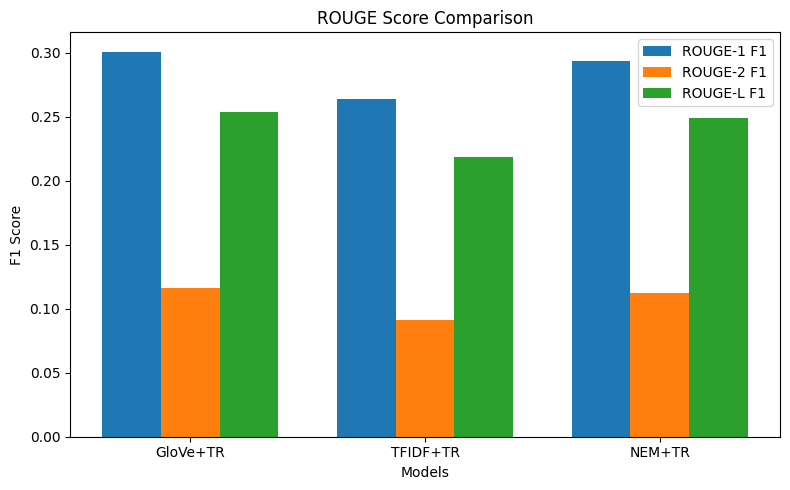

In [285]:
import matplotlib.pyplot as plt
import numpy as np
models = ["GloVe+TR", "TFIDF+TR", "NEM+TR"]
r1 = [0.301, 0.264, 0.294]
r2 = [0.116, 0.091, 0.112]
rl = [0.254, 0.219, 0.249]
x = np.arange(len(models))
width = 0.25
plt.figure(figsize=(8,5))
plt.bar(x - width, r1, width, label="ROUGE-1 F1")
plt.bar(x, r2, width, label="ROUGE-2 F1")
plt.bar(x + width, rl, width, label="ROUGE-L F1")
plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("ROUGE Score Comparison")
plt.legend()
plt.tight_layout()
plt.show()